In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

C1


RESULTADOS DEL CASO BASE BATCH
Horas operativas anuales       : 4,176 h
Factor de carga                : 47.67 %
Demanda térmica anual          : 11,972.72 MWh_th
Aporte solar útil anual        : 6,792.71 MWh_th
Aporte auxiliar anual          : 5,180.07 MWh_th
Fracción solar anual           : 56.73 %
----------------------------------------------------------------
Energía que sale del campo     : 7,335.67 MWh_th
Pérdidas térmicas anuales TES  : 444.14 MWh_th
  - durante operación          : 210.68 MWh_th
  - fuera del horario          : 233.45 MWh_th
----------------------------------------------------------------
Horas con campo activo y planta apagada : 197 h
Energía de campo fuera del horario      : 594.12 MWh_th
Horas con indicador de desenfoque       : 863 h
Horas de desenfoque fuera del horario   : 44 h
Fracción de foco media en esas horas    : 0.543
Nota: la energía de campo fuera del horario no debe interpretarse automáticamente como energía perdida; una parte puede almacenars

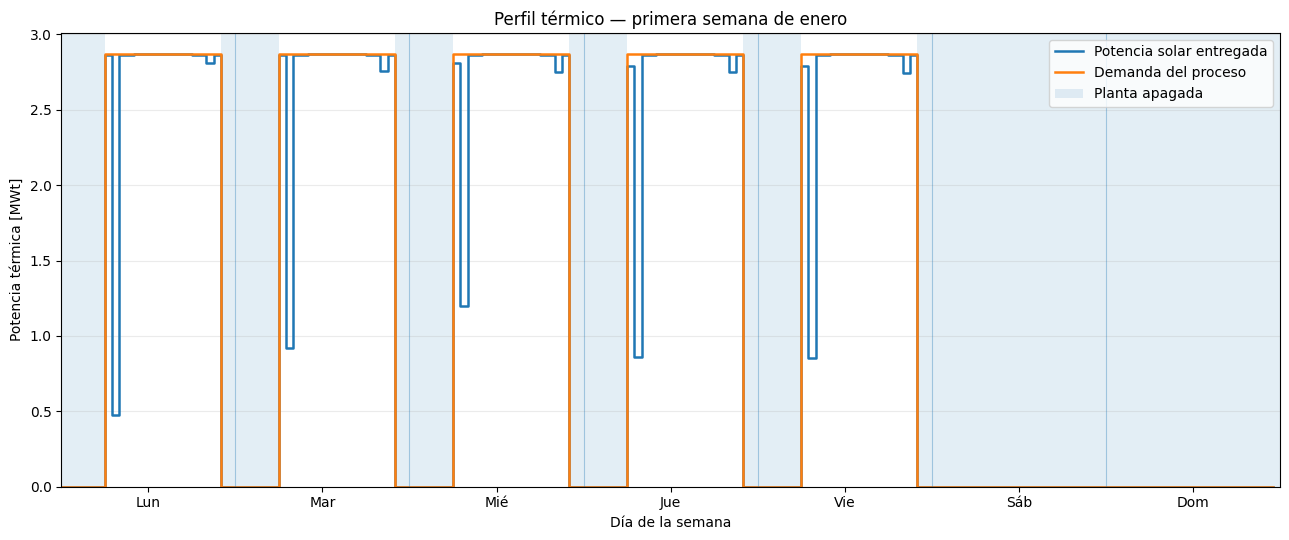

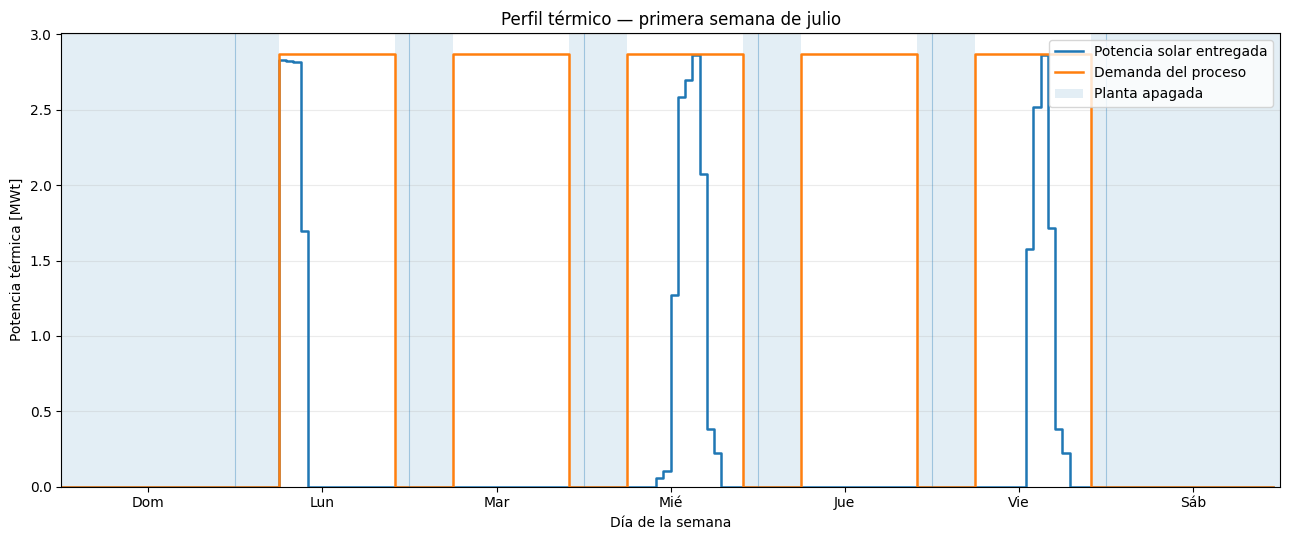

C:\Users\chaco\AppData\Local\Temp\ipykernel_13280\3013049687.py:273: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguous
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  fechas = pd.to_datetime(sam["Time stamp"], format="%b %d, %I:%M %p")


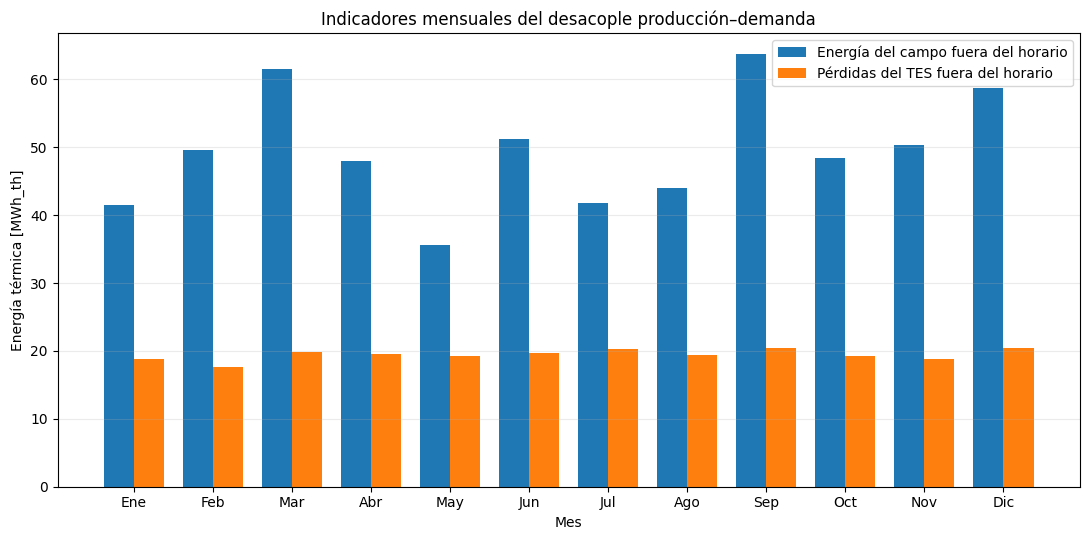

In [2]:
RUTA_SAM = Path("SAM_results_batch.csv")
RUTA_DISPATCH = Path("dispatch_batch.xlsx")
CARPETA_SALIDA = Path("graficos_C1")
CARPETA_SALIDA.mkdir(exist_ok=True)

Q_NOMINAL_KWT = 2867.03

DELTA_T_H = 1.0
TOL = 1e-6

COL_Q_SOLAR = "System net thermal power w/ avail. derate | (kWt)"
COL_Q_CAMPO = "Field thermal power leaving in HTF | (MWt)"
COL_FOCUS = "Field optical focus fraction"
COL_TES_LOSS = "TES thermal losses | (MWt)"
COL_DNI = "Resource Beam normal irradiance | (W/m2)"


def cargar_dispatch(ruta: Path) -> np.ndarray:
    """Carga la primera columna numérica del archivo de despacho."""
    if ruta.suffix.lower() in {".xlsx", ".xls"}:
        bruto = pd.read_excel(ruta, header=None).iloc[:, 0]
    else:
        bruto = pd.read_csv(ruta, header=None).iloc[:, 0]

    dispatch = pd.to_numeric(bruto, errors="coerce").dropna().to_numpy(dtype=float)

    if len(dispatch) != 8760:
        raise ValueError(f"El despacho debe tener 8760 valores; se encontraron {len(dispatch)}.")

    if not np.isin(dispatch, [0.0, 1.0]).all():
        raise ValueError("El despacho debe contener solamente valores 0.0 y 1.0.")

    return dispatch


def sombrear_horas_apagadas(ax, dispatch_segmento: np.ndarray) -> None:
    """Sombrea los intervalos horarios en que dispatch = 0."""
    apagado = dispatch_segmento == 0
    cambios = np.diff(np.r_[False, apagado, False].astype(int))
    inicios = np.where(cambios == 1)[0]
    finales = np.where(cambios == -1)[0]

    primera = True
    for inicio, final in zip(inicios, finales):
        ax.axvspan(
            inicio,
            final,
            alpha=0.12,
            label="Planta apagada" if primera else None,
        )
        primera = False


def etiquetas_dias(inicio_hora: int) -> tuple[np.ndarray, list[str]]:
    """Genera posiciones y nombres de días según el calendario del despacho."""
    dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
    dia_inicial = (inicio_hora // 24) % 7
    posiciones = np.arange(12, 168, 24)
    etiquetas = [dias[(dia_inicial + i) % 7] for i in range(7)]
    return posiciones, etiquetas


def graficar_semana(
    df: pd.DataFrame,
    inicio: int,
    fin: int,
    titulo: str,
    nombre_archivo: str,
) -> None:
    """Grafica potencia solar útil y demanda durante una semana."""
    semana = df.iloc[inicio:fin].copy().reset_index(drop=True)
    x = np.arange(len(semana))

    fig, ax = plt.subplots(figsize=(13, 5.5))

    ax.step(
        x,
        semana["Q_solar_MWt"],
        where="post",
        linewidth=1.8,
        label="Potencia solar entregada",
    )
    ax.step(
        x,
        semana["Q_demanda_MWt"],
        where="post",
        linewidth=1.8,
        label="Demanda del proceso",
    )

    sombrear_horas_apagadas(ax, semana["dispatch"].to_numpy())

    for limite in np.arange(24, 168, 24):
        ax.axvline(limite, linewidth=0.8, alpha=0.35)

    posiciones, etiquetas = etiquetas_dias(inicio)
    ax.set_xticks(posiciones)
    ax.set_xticklabels(etiquetas)

    ax.set_xlim(0, 168)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Día de la semana")
    ax.set_ylabel("Potencia térmica [MWt]")
    ax.set_title(titulo)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper right")

    fig.tight_layout()
    fig.savefig(CARPETA_SALIDA / nombre_archivo, dpi=300, bbox_inches="tight")
    plt.show()

sam = pd.read_csv(RUTA_SAM, encoding="utf-8-sig")
dispatch = cargar_dispatch(RUTA_DISPATCH)

columnas_requeridas = [
    "Time stamp",
    COL_Q_SOLAR,
    COL_Q_CAMPO,
    COL_FOCUS,
    COL_TES_LOSS,
    COL_DNI,
]

faltantes = [col for col in columnas_requeridas if col not in sam.columns]
if faltantes:
    raise KeyError(f"Faltan columnas en el CSV de SAM: {faltantes}")

if len(sam) != 8760:
    raise ValueError(f"El archivo de SAM debe tener 8760 filas; tiene {len(sam)}.")

# Series principales.
sam["dispatch"] = dispatch
sam["Q_solar_MWt"] = pd.to_numeric(sam[COL_Q_SOLAR], errors="coerce") / 1000.0
sam["Q_campo_MWt"] = pd.to_numeric(sam[COL_Q_CAMPO], errors="coerce")
sam["focus_fraction"] = pd.to_numeric(sam[COL_FOCUS], errors="coerce")
sam["TES_loss_MWt"] = pd.to_numeric(sam[COL_TES_LOSS], errors="coerce")
sam["DNI_Wm2"] = pd.to_numeric(sam[COL_DNI], errors="coerce")

# Demanda nominal modulada por el despacho.
sam["Q_demanda_MWt"] = (Q_NOMINAL_KWT / 1000.0) * sam["dispatch"]

# Fórmula fallback solicitada por el enunciado.
sam["Q_aux_MWt"] = np.maximum(
    sam["Q_demanda_MWt"] - sam["Q_solar_MWt"],
    0.0,
)

horas_operativas = sam["dispatch"].sum()
factor_carga = horas_operativas / 8760.0

E_demanda_MWh = (sam["Q_demanda_MWt"] * DELTA_T_H).sum()
E_solar_MWh = (sam["Q_solar_MWt"] * DELTA_T_H).sum()
E_aux_MWh = (sam["Q_aux_MWt"] * DELTA_T_H).sum()

SF = E_solar_MWh / (E_solar_MWh + E_aux_MWh)

E_campo_MWh = (sam["Q_campo_MWt"] * DELTA_T_H).sum()
E_perdidas_TES_MWh = (sam["TES_loss_MWt"] * DELTA_T_H).sum()

mask_desacople = (sam["dispatch"] == 0) & (sam["Q_campo_MWt"] > TOL)
horas_desacople = int(mask_desacople.sum())
E_campo_fuera_horario_MWh = (
    sam.loc[mask_desacople, "Q_campo_MWt"] * DELTA_T_H
).sum()

E_perdidas_TES_fuera_MWh = (
    sam.loc[sam["dispatch"] == 0, "TES_loss_MWt"] * DELTA_T_H
).sum()
E_perdidas_TES_operando_MWh = (
    sam.loc[sam["dispatch"] == 1, "TES_loss_MWt"] * DELTA_T_H
).sum()

mask_desenfoque = (sam["DNI_Wm2"] > 0) & (sam["focus_fraction"] < 0.999)
horas_desenfoque = int(mask_desenfoque.sum())
horas_desenfoque_fuera = int((mask_desenfoque & (sam["dispatch"] == 0)).sum())
fraccion_foco_media = sam.loc[mask_desenfoque, "focus_fraction"].mean()

print("\n" + "=" * 64)
print("RESULTADOS DEL CASO BASE BATCH")
print("=" * 64)
print(f"Horas operativas anuales       : {horas_operativas:,.0f} h")
print(f"Factor de carga                : {100 * factor_carga:,.2f} %")
print(f"Demanda térmica anual          : {E_demanda_MWh:,.2f} MWh_th")
print(f"Aporte solar útil anual        : {E_solar_MWh:,.2f} MWh_th")
print(f"Aporte auxiliar anual          : {E_aux_MWh:,.2f} MWh_th")
print(f"Fracción solar anual           : {100 * SF:,.2f} %")
print("-" * 64)
print(f"Energía que sale del campo     : {E_campo_MWh:,.2f} MWh_th")
print(f"Pérdidas térmicas anuales TES  : {E_perdidas_TES_MWh:,.2f} MWh_th")
print(f"  - durante operación          : {E_perdidas_TES_operando_MWh:,.2f} MWh_th")
print(f"  - fuera del horario          : {E_perdidas_TES_fuera_MWh:,.2f} MWh_th")
print("-" * 64)
print(f"Horas con campo activo y planta apagada : {horas_desacople} h")
print(f"Energía de campo fuera del horario      : {E_campo_fuera_horario_MWh:,.2f} MWh_th")
print(f"Horas con indicador de desenfoque       : {horas_desenfoque} h")
print(f"Horas de desenfoque fuera del horario   : {horas_desenfoque_fuera} h")
print(f"Fracción de foco media en esas horas    : {fraccion_foco_media:,.3f}")
print("=" * 64)
print(
    "Nota: la energía de campo fuera del horario no debe interpretarse "
    "automáticamente como energía perdida; una parte puede almacenarse."
)
print(
    "La fracción de foco permite identificar horas de desenfoque, pero no "
    "cuantificar por sí sola la energía rechazada."
)

resumen = pd.DataFrame(
    {
        "Indicador": [
            "Horas operativas",
            "Factor de carga",
            "Demanda térmica anual",
            "Aporte solar útil anual",
            "Aporte auxiliar anual",
            "Fracción solar anual",
            "Energía térmica que sale del campo",
            "Pérdidas térmicas anuales del TES",
            "Pérdidas TES fuera del horario",
            "Horas con campo activo y planta apagada",
            "Energía de campo fuera del horario",
            "Horas con indicador de desenfoque",
        ],
        "Valor": [
            horas_operativas,
            factor_carga,
            E_demanda_MWh,
            E_solar_MWh,
            E_aux_MWh,
            SF,
            E_campo_MWh,
            E_perdidas_TES_MWh,
            E_perdidas_TES_fuera_MWh,
            horas_desacople,
            E_campo_fuera_horario_MWh,
            horas_desenfoque,
        ],
        "Unidad": [
            "h/año",
            "-",
            "MWh_th/año",
            "MWh_th/año",
            "MWh_th/año",
            "-",
            "MWh_th/año",
            "MWh_th/año",
            "MWh_th/año",
            "h/año",
            "MWh_th/año",
            "h/año",
        ],
    }
)
resumen.to_csv("resumen_C1_batch.csv", index=False, encoding="utf-8-sig")

graficar_semana(
    sam,
    inicio=0,
    fin=168,
    titulo="Perfil térmico — primera semana de enero",
    nombre_archivo="perfil_verano_batch.png",
)

# Invierno: horas 4344 a 4511.
graficar_semana(
    sam,
    inicio=4344,
    fin=4512,
    titulo="Perfil térmico — primera semana de julio",
    nombre_archivo="perfil_invierno_batch.png",
)

fechas = pd.to_datetime(sam["Time stamp"], format="%b %d, %I:%M %p")
sam["mes"] = fechas.dt.month

sam["Q_campo_fuera_MWt"] = np.where(
    sam["dispatch"] == 0,
    sam["Q_campo_MWt"],
    0.0,
)
sam["TES_loss_fuera_MWt"] = np.where(
    sam["dispatch"] == 0,
    sam["TES_loss_MWt"],
    0.0,
)

mensual = sam.groupby("mes", as_index=True)[
    ["Q_campo_fuera_MWt", "TES_loss_fuera_MWt"]
].sum()

meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
x = np.arange(12)
ancho = 0.38

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(
    x - ancho / 2,
    mensual["Q_campo_fuera_MWt"],
    width=ancho,
    label="Energía del campo fuera del horario",
)
ax.bar(
    x + ancho / 2,
    mensual["TES_loss_fuera_MWt"],
    width=ancho,
    label="Pérdidas del TES fuera del horario",
)
ax.set_xticks(x)
ax.set_xticklabels(meses)
ax.set_xlabel("Mes")
ax.set_ylabel("Energía térmica [MWh_th]")
ax.set_title("Indicadores mensuales del desacople producción–demanda")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(
    CARPETA_SALIDA / "desacople_mensual_batch.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

C2

In [3]:
dispatch_continuo = []

for i in range(8760):
    dispatch_continuo.append(1.0)

archivo = open("dispatch_continuo.csv", "w")

for valor in dispatch_continuo:
    archivo.write(str(valor) + "\n")

archivo.close()

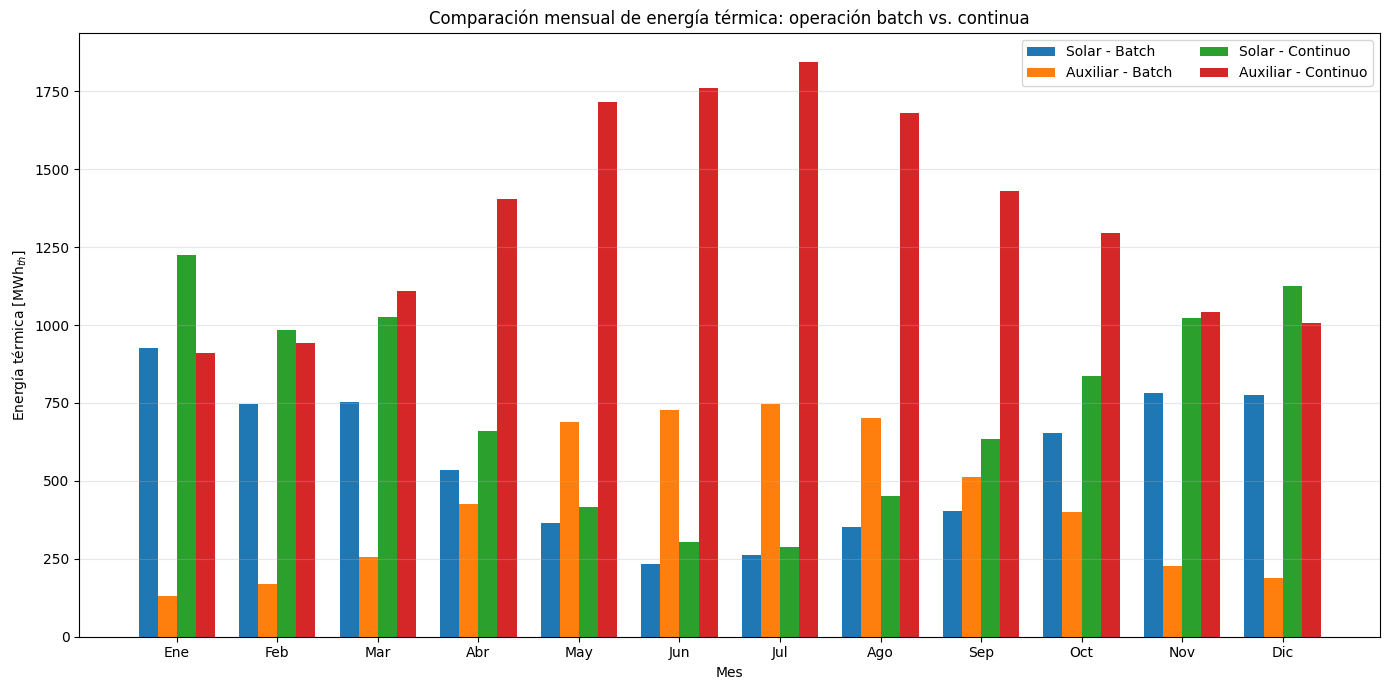


RESUMEN ANUAL
           Escenario  Q_solar [MWh/año]  Q_aux [MWh/año]  Fracción solar [%]
Batch (L-V, 06-22 h)            6792.71          5180.07               56.73
     Continuo (24/7)            8972.31         16142.95               35.72

Gráfico guardado en: grafico_C2_batch_vs_continuo.png
Resumen guardado en: resumen_C2.csv


In [4]:
archivo_batch = "SAM_results_batch.csv"
archivo_continuo = "SAM_results_continuo.csv"

# Potencia térmica nominal del proceso obtenida del análisis Pinch
Q_NOMINAL_KWT = 2867.03

# Columna de calor solar útil entregado por SAM
COLUMNA_SOLAR = "System net thermal power w/ avail. derate | (kWt)"

# ------------------------------------------------------------
# 1. Cargar resultados de SAM
# ------------------------------------------------------------
batch = pd.read_csv(archivo_batch)
continuo = pd.read_csv(archivo_continuo)

if len(batch) != 8760 or len(continuo) != 8760:
    raise ValueError("Ambos archivos deben contener exactamente 8760 filas horarias.")

if COLUMNA_SOLAR not in batch.columns or COLUMNA_SOLAR not in continuo.columns:
    raise KeyError(f"No se encontró la columna requerida: {COLUMNA_SOLAR}")

# ------------------------------------------------------------
# 2. Crear los vectores de despacho
# ------------------------------------------------------------
horas = np.arange(8760)
dia_del_anio = horas // 24
hora_local = horas % 24
dia_semana = dia_del_anio % 7

dispatch_batch = np.where(
    (dia_semana < 5) & (hora_local >= 6) & (hora_local < 22),
    1.0,
    0.0
)

dispatch_continuo = np.ones(8760)

# ------------------------------------------------------------
# 3. Calcular demanda, aporte solar y aporte auxiliar
# ------------------------------------------------------------
demanda_batch = Q_NOMINAL_KWT * dispatch_batch
demanda_continuo = Q_NOMINAL_KWT * dispatch_continuo

q_solar_batch = batch[COLUMNA_SOLAR].to_numpy(dtype=float)
q_solar_continuo = continuo[COLUMNA_SOLAR].to_numpy(dtype=float)

# Fórmula fallback indicada en la tarea
q_aux_batch = np.maximum(demanda_batch - q_solar_batch, 0.0)
q_aux_continuo = np.maximum(demanda_continuo - q_solar_continuo, 0.0)

# ------------------------------------------------------------
# 4. Sumar la energía de cada mes
#    Como los datos son horarios, kW x 1 h = kWh.
#    Se divide por 1000 para obtener MWh.
# ------------------------------------------------------------
dias_por_mes = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
         "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

limites = np.cumsum([0] + [dias * 24 for dias in dias_por_mes])

solar_batch_mensual = []
aux_batch_mensual = []
solar_continuo_mensual = []
aux_continuo_mensual = []

for i in range(12):
    inicio = limites[i]
    fin = limites[i + 1]

    solar_batch_mensual.append(q_solar_batch[inicio:fin].sum() / 1000)
    aux_batch_mensual.append(q_aux_batch[inicio:fin].sum() / 1000)
    solar_continuo_mensual.append(q_solar_continuo[inicio:fin].sum() / 1000)
    aux_continuo_mensual.append(q_aux_continuo[inicio:fin].sum() / 1000)

# ------------------------------------------------------------
# 5. Crear el gráfico de barras comparativo
# ------------------------------------------------------------
x = np.arange(len(meses))
ancho = 0.19

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(x - 1.5 * ancho, solar_batch_mensual, ancho,
       label="Solar - Batch")
ax.bar(x - 0.5 * ancho, aux_batch_mensual, ancho,
       label="Auxiliar - Batch")
ax.bar(x + 0.5 * ancho, solar_continuo_mensual, ancho,
       label="Solar - Continuo")
ax.bar(x + 1.5 * ancho, aux_continuo_mensual, ancho,
       label="Auxiliar - Continuo")

ax.set_title("Comparación mensual de energía térmica: operación batch vs. continua")
ax.set_xlabel("Mes")
ax.set_ylabel("Energía térmica [MWh$_{th}$]")
ax.set_xticks(x)
ax.set_xticklabels(meses)
ax.grid(axis="y", alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()

ruta_grafico = "grafico_C2_batch_vs_continuo.png"
fig.savefig(ruta_grafico, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6. Resumen anual
# ------------------------------------------------------------
q_solar_batch_anual = q_solar_batch.sum() / 1000
q_aux_batch_anual = q_aux_batch.sum() / 1000
sf_batch = 100 * q_solar_batch.sum() / (q_solar_batch.sum() + q_aux_batch.sum())

q_solar_cont_anual = q_solar_continuo.sum() / 1000
q_aux_cont_anual = q_aux_continuo.sum() / 1000
sf_cont = 100 * q_solar_continuo.sum() / (
    q_solar_continuo.sum() + q_aux_continuo.sum()
)

resumen = pd.DataFrame({
    "Escenario": ["Batch (L-V, 06-22 h)", "Continuo (24/7)"],
    "Q_solar [MWh/año]": [q_solar_batch_anual, q_solar_cont_anual],
    "Q_aux [MWh/año]": [q_aux_batch_anual, q_aux_cont_anual],
    "Fracción solar [%]": [sf_batch, sf_cont]
})

ruta_resumen = "resumen_C2.csv"
resumen.to_csv(ruta_resumen, index=False)

print("\nRESUMEN ANUAL")
print(resumen.round(2).to_string(index=False))
print(f"\nGráfico guardado en: {ruta_grafico}")
print(f"Resumen guardado en: {ruta_resumen}")


C3

,Solar Multiple,Fracción Solar [%]
0,1.0,40.66
1,1.2,56.73
2,1.4,56.73
3,1.6,56.73
4,1.8,56.73
5,2.0,56.73
6,2.2,56.73
7,2.4,61.05
8,2.6,61.05
9,2.8,61.05


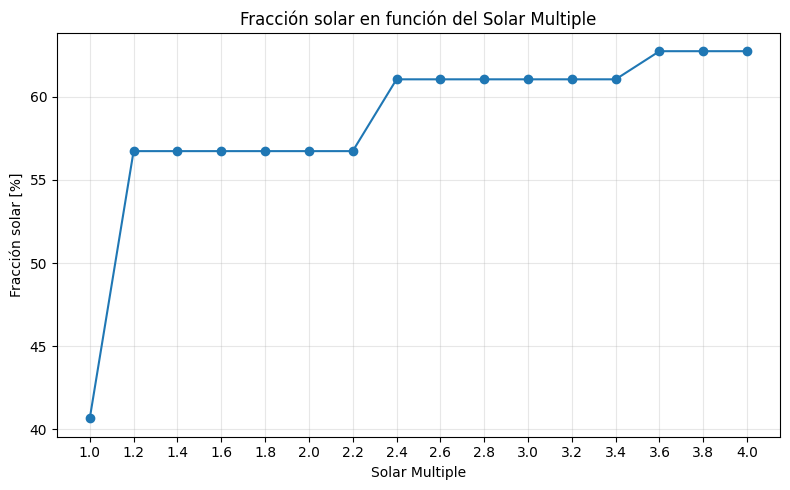

In [5]:
parametrico = pd.read_csv("resultados_parametrico.csv")

valores_sm = parametrico.iloc[0, 1:].astype(float).to_numpy()

filas_solar = parametrico["run"].str.contains("System net thermal power",na=False)

datos_solar = parametrico.loc[filas_solar,parametrico.columns[1:]]

datos_solar = datos_solar.astype(float)
datos_solar = datos_solar.reset_index(drop=True)

fracciones_solares = []


for columna in datos_solar.columns:

    q_solar = datos_solar[columna].to_numpy()

    q_aux = np.maximum(demanda_batch - q_solar,0)

    sf = 100 * q_solar.sum() / (q_solar.sum() + q_aux.sum())

    fracciones_solares.append(sf)


tabla_resumen = pd.DataFrame({
    "Solar Multiple": valores_sm,
    "Fracción Solar [%]": fracciones_solares
})

tabla_resumen = tabla_resumen.sort_values("Solar Multiple").reset_index(drop=True)

display(tabla_resumen.round(2))

tabla_resumen.to_csv(
    "tabla_resumen_C3.csv",
    index=False
)

plt.figure(figsize=(8, 5))

plt.plot(
    tabla_resumen["Solar Multiple"],
    tabla_resumen["Fracción Solar [%]"],
    marker="o"
)

plt.title("Fracción solar en función del Solar Multiple")
plt.xlabel("Solar Multiple")
plt.ylabel("Fracción solar [%]")

plt.grid(True, alpha=0.3)
plt.xticks(tabla_resumen["Solar Multiple"])
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    "fraccion_solar_vs_SM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Parte D

In [10]:
area_apertura = 10560
horas_tes = 4

Q_SOLAR_ANUAL_KWH = q_solar_batch_anual * 1000

c_ptc = 400
c_tes = 30
bos_porcentaje = 0.20
om_porcentaje = 0.02

r = 0.07
n = 25

precio_gn = 0.045
eficiencia_caldera = 0.88

crf = r * (1 + r)**n / ((1 + r)**n - 1)

capex_ptc = area_apertura * c_ptc

capacidad_tes = Q_NOMINAL_KWT * horas_tes

capex_tes = capacidad_tes * c_tes

bos = bos_porcentaje * (capex_ptc + capex_tes)

capex_total = capex_ptc + capex_tes + bos

om_anual = om_porcentaje * capex_total

lcoh_solar = (capex_total * crf + om_anual) / Q_SOLAR_ANUAL_KWH

lcoh_gn = precio_gn / eficiencia_caldera

lcoh_solar_mwh = lcoh_solar * 1000

lcoh_gn_mwh = lcoh_gn * 1000


print("CRF:", round(crf, 4))

print("CAPEX colectores:",round(capex_ptc, 2),"USD")

print("Capacidad TES:",round(capacidad_tes, 2),"kWh_th")

print("CAPEX TES:",round(capex_tes, 2),"USD")

print("BOS:",round(bos, 2),"USD")

print("CAPEX total:",round(capex_total, 2),"USD")

print("O&M anual:",round(om_anual, 2),"USD/año")

print("LCoH solar:",round(lcoh_solar_mwh, 2),"USD/MWh_th")

print("LCoH gas natural:",round(lcoh_gn_mwh, 2),"USD/MWh_th")

CRF: 0.0858
CAPEX colectores: 4224000 USD
Capacidad TES: 11468.12 kWh_th
CAPEX TES: 344043.6 USD
BOS: 913608.72 USD
CAPEX total: 5481652.32 USD
O&M anual: 109633.05 USD/año
LCoH solar: 85.39 USD/MWh_th
LCoH gas natural: 51.14 USD/MWh_th


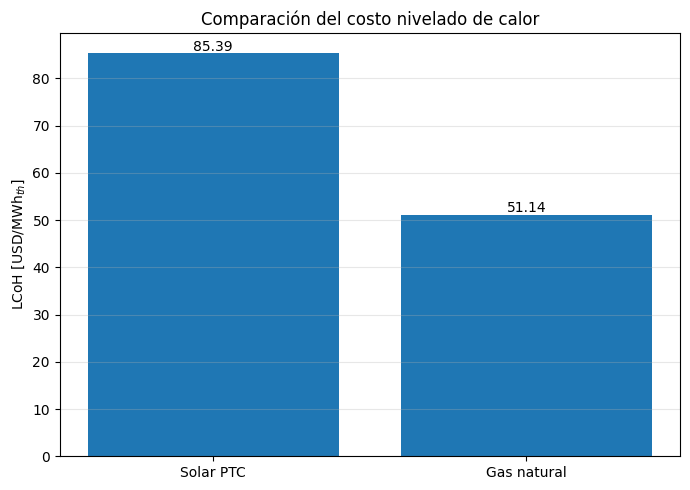

Ahorro anual: -232661.98 USD/año
No existe payback porque el ahorro anual es negativo.


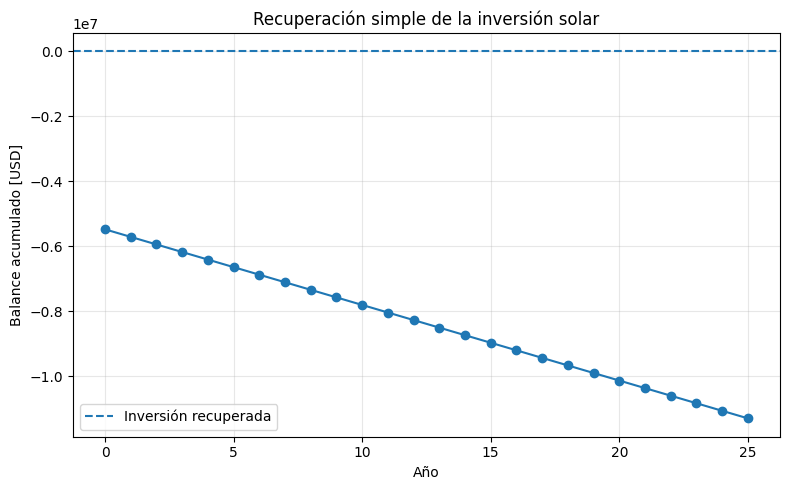

CAPEX de paridad: 226.48 USD/m²


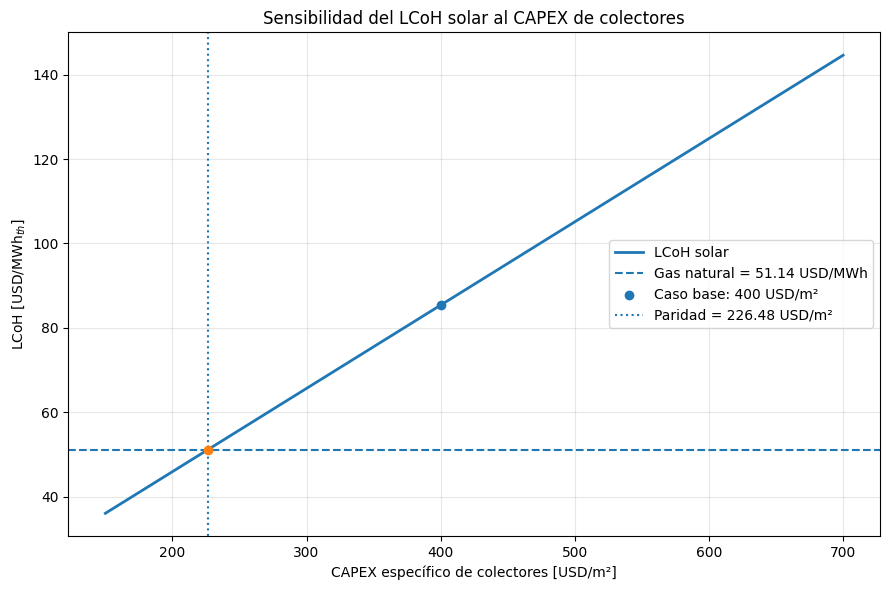

,Indicador,Valor,Unidad
0,LCoH solar,85.39,USD/MWh_th
1,LCoH gas natural,51.14,USD/MWh_th
2,Ahorro anual,-232661.98,USD/año
3,Payback simple,NaN,años
4,CAPEX de paridad,226.48,USD/m²


In [11]:
tecnologias = ["Solar PTC", "Gas natural"]
valores_lcoh = [lcoh_solar_mwh, lcoh_gn_mwh]

plt.figure(figsize=(7, 5))

barras = plt.bar(tecnologias, valores_lcoh)

for barra, valor in zip(barras, valores_lcoh):

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{valor:.2f}",
        ha="center"
    )

plt.title("Comparación del costo nivelado de calor")
plt.ylabel("LCoH [USD/MWh$_{th}$]")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "comparacion_LCoH.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# D.3.b AHORRO ANUAL Y PAYBACK SIMPLE
# ============================================================

# Como Q_SOLAR_ANUAL_KWH está en kWh/año y los LCoH en USD/kWh,
# el resultado queda directamente en USD/año.

ahorro_anual = Q_SOLAR_ANUAL_KWH * (
    lcoh_gn - lcoh_solar
)

print("Ahorro anual:", round(ahorro_anual, 2), "USD/año")


if ahorro_anual > 0:

    payback = capex_total / ahorro_anual

    print("Payback simple:", round(payback, 2), "años")

else:

    payback = np.nan

    print("No existe payback porque el ahorro anual es negativo.")

# ============================================================
# GRÁFICO DEL PAYBACK SIMPLE
# ============================================================

anios = np.arange(0, n + 1)

balance_acumulado = (
    -capex_total
    + ahorro_anual * anios
)

plt.figure(figsize=(8, 5))

plt.plot(
    anios,
    balance_acumulado,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    label="Inversión recuperada"
)

if ahorro_anual > 0 and payback <= n:

    plt.axvline(
        payback,
        linestyle="--",
        label=f"Payback = {payback:.2f} años"
    )

plt.title("Recuperación simple de la inversión solar")
plt.xlabel("Año")
plt.ylabel("Balance acumulado [USD]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "payback_simple.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# D.3.c SENSIBILIDAD DEL LCoH AL CAPEX DE COLECTORES
# ============================================================

valores_c_ptc = np.linspace(150, 700, 100)

lcoh_sensibilidad = []


for c_ptc_variable in valores_c_ptc:

    capex_ptc_variable = (
        area_apertura * c_ptc_variable
    )

    bos_variable = bos_porcentaje * (
        capex_ptc_variable + capex_tes
    )

    capex_total_variable = (
        capex_ptc_variable
        + capex_tes
        + bos_variable
    )

    om_anual_variable = (
        om_porcentaje
        * capex_total_variable
    )

    lcoh_variable = (
        capex_total_variable * crf
        + om_anual_variable
    ) / Q_SOLAR_ANUAL_KWH

    lcoh_sensibilidad.append(
        lcoh_variable * 1000
    )


lcoh_sensibilidad = np.array(
    lcoh_sensibilidad
)


# ============================================================
# CÁLCULO DEL CAPEX DE PARIDAD
# ============================================================

if (
    lcoh_gn_mwh >= lcoh_sensibilidad.min()
    and lcoh_gn_mwh <= lcoh_sensibilidad.max()
):

    capex_paridad = np.interp(
        lcoh_gn_mwh,
        lcoh_sensibilidad,
        valores_c_ptc
    )

    print(
        "CAPEX de paridad:",
        round(capex_paridad, 2),
        "USD/m²"
    )

else:

    capex_paridad = np.nan

    print(
        "El CAPEX de paridad queda fuera "
        "del rango de 150 a 700 USD/m²."
    )


# ============================================================
# GRÁFICO DE SENSIBILIDAD
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    valores_c_ptc,
    lcoh_sensibilidad,
    linewidth=2,
    label="LCoH solar"
)

plt.axhline(
    lcoh_gn_mwh,
    linestyle="--",
    label=f"Gas natural = {lcoh_gn_mwh:.2f} USD/MWh"
)

# Punto del caso base
plt.scatter(
    c_ptc,
    lcoh_solar_mwh,
    label=f"Caso base: {c_ptc} USD/m²",
    zorder=5
)

# Mostrar la paridad solo si está dentro del rango
if not np.isnan(capex_paridad):

    plt.axvline(
        capex_paridad,
        linestyle=":",
        label=f"Paridad = {capex_paridad:.2f} USD/m²"
    )

    plt.scatter(
        capex_paridad,
        lcoh_gn_mwh,
        zorder=5
    )

plt.title("Sensibilidad del LCoH solar al CAPEX de colectores")
plt.xlabel("CAPEX específico de colectores [USD/m²]")
plt.ylabel("LCoH [USD/MWh$_{th}$]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "sensibilidad_LCoH_CAPEX.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# TABLA RESUMEN D.3
# ============================================================

tabla_d3 = pd.DataFrame({
    "Indicador": [
        "LCoH solar",
        "LCoH gas natural",
        "Ahorro anual",
        "Payback simple",
        "CAPEX de paridad"
    ],

    "Valor": [
        lcoh_solar_mwh,
        lcoh_gn_mwh,
        ahorro_anual,
        payback,
        capex_paridad
    ],

    "Unidad": [
        "USD/MWh_th",
        "USD/MWh_th",
        "USD/año",
        "años",
        "USD/m²"
    ]
})

display(tabla_d3.round(2))